SETUP

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/ecommerce.csv")
df.head()

,customer_id,session_id,visit_date,device_type,user_type,marketing_channel,product_id,product_category,unit_price,quantity,...,review_text,review_helpful_votes,payment_method,visit_day,visit_month,visit_weekday,visit_season,session_duration_bucket,revenue_normalized,location
0,1803,0,28-11-2024,2,1,2,894,6,651.57,1,...,1,0,1,28,11,3,0,Long,0.000000,209
1,7964,1,25-09-2024,2,0,4,844,2,945.27,4,...,1,0,2,25,9,2,0,Long,0.000000,213
2,6890,2,31-05-2024,1,1,0,865,0,400.44,4,...,1,0,2,31,5,4,1,Short,0.000000,10
3,4949,3,30-01-2024,1,0,2,851,3,1268.54,2,...,10,4,1,30,1,1,3,Very Long,0.305504,46
4,4896,4,25-02-2024,1,1,5,794,3,880.81,3,...,1,0,1,25,2,6,3,Very Short,0.000000,118


USER-PRODUCT MATRIX

In [3]:
user_product = df.pivot_table(
    index='customer_id',
    columns='product_category',
    values='purchased',
    aggfunc='sum',
    fill_value=0
)

user_product.head()

product_category,0,1,2,3,4,5,6,7
customer_id,,,,,,,,
1000,0,0,0,0,0,0,0,1
1001,0,0,0,0,0,0,0,0
1002,0,0,0,0,0,0,0,0
1003,0,1,0,0,0,0,0,0
1004,0,0,0,0,0,0,0,0


SIMILAR USERS

In [4]:
from sklearn.metrics.pairwise import cosine_similarity

user_similarity = cosine_similarity(user_product)

user_similarity_df = pd.DataFrame(
    user_similarity,
    index=user_product.index,
    columns=user_product.index
)

user_similarity_df.head()

customer_id,1000,1001,1002,1003,1004,1005,1006,1007,1008,1009,...,9989,9990,9991,9992,9993,9994,9995,9996,9997,9998
customer_id,,,,,,,,,,,,,,,,,,,,,
1000,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.707107,0.0,0.0,0.0,0.0,0.0
1001,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
1002,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
1003,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
1004,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0


In [5]:
popular_products = df.groupby('product_category')['purchased'].sum().sort_values(ascending=False)

popular_products.head()

product_category
6    768
5    728
4    727
2    721
0    700
Name: purchased, dtype: int64

RECOMMEND FUNCTION

In [6]:
def recommend_products(user_id, top_n=5):
    
    user_data = user_product.loc[user_id]
    
    # If user has no purchase history → fallback
    if user_data.sum() == 0:
        print("⚠️ New user → showing popular products")
        return popular_products.head(top_n)
    
    similar_users = user_similarity_df[user_id].sort_values(ascending=False)[1:10]
    
    similar_users_data = user_product.loc[similar_users.index]
    
    recommendations = similar_users_data.sum()
    
    recommendations = recommendations[user_data == 0]
    
    recommendations = recommendations[recommendations > 0]
    
    # If still empty → fallback
    if recommendations.empty:
        print("⚠️ No strong similarity → showing popular products")
        return popular_products.head(top_n)
    
    return recommendations.sort_values(ascending=False).head(top_n)

TEST

In [7]:
recommend_products(1001)

⚠️ New user → showing popular products


product_category
6    768
5    728
4    727
2    721
0    700
Name: purchased, dtype: int64

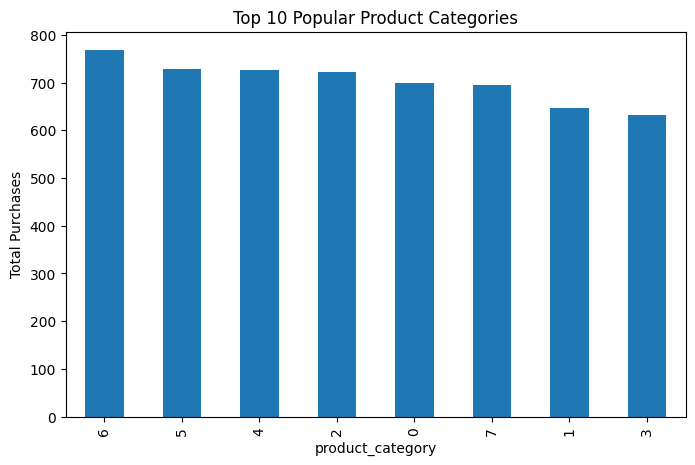

In [8]:
plt.figure(figsize=(8,5))
popular_products.head(10).plot(kind='bar')
plt.title("Top 10 Popular Product Categories")
plt.ylabel("Total Purchases")
plt.show()

In [9]:
popular_products.to_csv("../reports/popular_products.csv")